## In-memory graph

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/google/distributed_graph_flow/blob/main/doc/docs/tutorial/in_memory_graph.ipynb)

This tutorial explains how GF stores graphs in memory and shows you how to
inspect, create, modify, and transform them.

## Installing GF

Make sure your machine has a GPU or TPU, otherwise training is going to take forever.
If you are using Google Colab, you can get one for free. Just go to Edit > Notebook settings and select your hardware accelerator as TPU or GPU.

In [ ]:
# Install DGF (Distributed Graph Flow) and OGB (for the toy dataset).
!pip install dgf ogb -U

## Importing libraries

In [ ]:
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"

import copy
import dgf  # Import Graph Flow
import numpy as np

## Creating a graph in-memory

A graph is always attached to a schema. Let's first create our schema:

Our graph will have two nodesets, "nodeset_1" and "nodeset_2", and two
edgesets. The edgeset "edgeset_1" connects nodes within "nodeset_1" (a self-loop
edgeset), and "edgeset_2" connects nodes from "nodeset_1" to "nodeset_2".
Additionally, the "nodeset_1" nodeset will have two features, "f1" and "f2".

**Note:**

-   The schema defines the relation between the nodesets/edgesets as well as the
    features (i.e., extra information attached to nodes and edges).
-   Plotting the schema (done below) will make this clearer :).

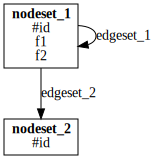

In [ ]:
schema = dgf.data.GraphSchema(
    node_sets={
        "nodeset_1": dgf.data.NodeSchema(
            features={
                "#id": dgf.data.FeatureSchema(
                    format=dgf.data.FeatureFormat.BYTES,
                    semantic=dgf.data.FeatureSemantic.PRIMARY_ID,
                ),
                "f1": dgf.data.FeatureSchema(
                    format=dgf.data.FeatureFormat.BYTES,
                    semantic=dgf.data.FeatureSemantic.CATEGORICAL,
                ),
                "f2": dgf.data.FeatureSchema(
                    format=dgf.data.FeatureFormat.FLOAT_32,
                    semantic=dgf.data.FeatureSemantic.NUMERICAL,
                ),
            }
        ),
        "nodeset_2": dgf.data.NodeSchema(
            features={
                "#id": dgf.data.FeatureSchema(
                    format=dgf.data.FeatureFormat.BYTES,
                    semantic=dgf.data.FeatureSemantic.PRIMARY_ID,
                )
            }
        ),
    },
    edge_sets={
        "edgeset_1": dgf.data.EdgeSchema(
            source="nodeset_1", target="nodeset_1"
        ),
        "edgeset_2": dgf.data.EdgeSchema(
            source="nodeset_1", target="nodeset_2"
        ),
    },
)

# Plot the schema
dgf.plot.plot_schema(schema)

**Remark:**

-   The schema is a pure dataclass object without any methods.
-   The `format` of a feature specifies its underlying data type (e.g., bytes,
    float32).
-   The `semantic` of a feature specifies how the feature should be interpreted
    (e.g., as numerical, categorical, or an embedding). Specifying the semantic
    is optional when creating a schema, but it is required by certain downstream
    tools. When you can, define the semantics.
-   Primary keys are optional for in-memory processing, but required for saving
    / restoring the graph from / to disk.
-   There are no reserved feature names. We used `#id` but we could also have
    called our primary key `id` or `my_primary_key`.

For complex schemas, printing it in text is a good alternative to plotting:

In [ ]:
dgf.print.schema(schema)

Graph Schema:

Node Sets:
  nodeset_1:
    | Feature   | Format   | Semantic    | Shape   | Num cat. vals   |
    |-----------|----------|-------------|---------|-----------------|
    | #id       | BYTES    | PRIMARY_ID  | None    | None            |
    | f1        | BYTES    | CATEGORICAL | None    | None            |
    | f2        | FLOAT_32 | NUMERICAL   | None    | None            |

  nodeset_2:
    | Feature   | Format   | Semantic   | Shape   | Num cat. vals   |
    |-----------|----------|------------|---------|-----------------|
    | #id       | BYTES    | PRIMARY_ID | None    | None            |


Edge Sets:
  edgeset_1: (Source: nodeset_1, Target: nodeset_1)
    (No features)

  edgeset_2: (Source: nodeset_1, Target: nodeset_2)
    (No features)



Let's create the graph data.

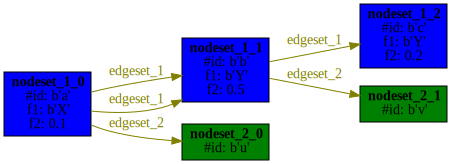

In [ ]:
graph = dgf.data.InMemoryGraph(
    node_sets={
        "nodeset_1": dgf.data.InMemoryNodeSet(
            num_nodes=3,
            features={
                "#id": np.array([b"a", b"b", b"c"]),
                "f1": np.array([b"X", b"Y", b"Y"]),
                "f2": np.array([0.1, 0.5, 0.2], dtype=np.float32),
            },
        ),
        "nodeset_2": dgf.data.InMemoryNodeSet(
            num_nodes=2,
            features={
                "#id": np.array([b"u", b"v"]),
            },
        ),
    },
    edge_sets={
        "edgeset_1": dgf.data.InMemoryEdgeSet(
            adjacency=np.array([
                [0, 0, 1],
                [1, 1, 2],
            ])
        ),
        "edgeset_2": dgf.data.InMemoryEdgeSet(
            adjacency=np.array([
                [0, 1],
                [0, 1],
            ])
        ),
    },
)

# Plot the graph
dgf.plot.plot_graph(graph, schema)

**Remark:**

-   The adjacency information for the edgesets is provided as a NumPy array of
    shape `[2, number of edges]`. The first row contains the source node
    indices, and the second row contains the target node indices.
-   A graph is essentially a dataclass containing a numpy array. DGF requires
    for features and adjacencies to be provided as numpy arrays.
-   GF support other equivalent graph classes using JAX or TensorFlow arrays
    (see later).

Checking the validity of a graph made by hand is always a good idea:

In [ ]:
dgf.validate.validate_graph(graph, schema)

## Modifying a graph in memory

The graph and schema are simply dataclasses with no logic / functions. You can
modify them directly. Now, let's create another edgeset.

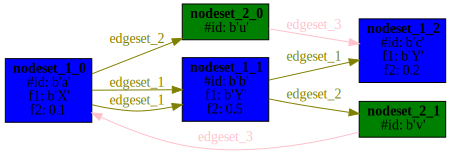

In [ ]:
schema.edge_sets["edgeset_3"] = dgf.data.EdgeSchema(
    source="nodeset_2", target="nodeset_1"
)
graph.edge_sets["edgeset_3"] = dgf.data.InMemoryEdgeSet(
    adjacency=np.array([
        [1, 0],
        [0, 2],
    ])
)
dgf.validate.validate_graph(graph, schema)
dgf.plot.plot_graph(graph, schema)

## Loading / saving graphs

Graphs can be saved to disk. Various formats are supported. See the "Graph File
Format" guide.

The GF format is the most efficient both to store small and large graphs.

In [ ]:
# Save the graph
dgf.io.write_graph(graph, schema, "/tmp/my_graph")

GFGraph written from memory in 0.01 seconds


GFGraph read in memory in 0.25 seconds


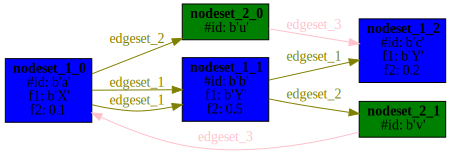

In [ ]:
# Load the graph
loaded_graph, loaded_schema = dgf.io.read_graph("/tmp/my_graph")
dgf.plot.plot_graph(loaded_graph, loaded_schema)

Graphs can be saved / restored using pickle. This option is very efficient, but
not portable at all.

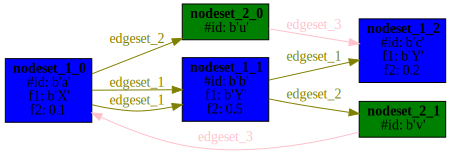

In [ ]:
import pickle

with open("/tmp/my_graph.pkl", "wb") as file:
  pickle.dump((graph, schema), file)

with open("/tmp/my_graph.pkl", "rb") as file:
  loaded_graph, loaded_schema = pickle.load(file)

dgf.plot.plot_graph(loaded_graph, loaded_schema)

Schemas (and most other GF configs) can be loaded / saved to json using the
`dataclass_json` library.

To make your life easy, we defined small utility functions:

In [ ]:
# Save the schema
dgf.io.write_schema(schema, "/tmp/my_schema.json")

In [ ]:
!head -n 10 /tmp/my_schema.json

{
  "node_sets": {
    "nodeset_1": {
      "features": {
        "#id": {
          "format": "BYTES",
          "semantic": "PRIMARY_ID",
          "shape": null,
          "num_categorical_values": null,
          "is_utf8_string": false


In [ ]:
# Reload the schema
loaded_schema = dgf.io.read_schema("/tmp/my_schema.json")
assert schema == loaded_schema

To load / save collections of graphs (e.g., to cache graph samples), you can use
the TF-GNN graph sampling format:

In [ ]:
# A list / generator of 5 graphs
def graphs():
  for _ in range(5):
    yield graph


# Save the graphs
dgf.io.write_tfgnn_graphs(
    graphs=graphs(), schema=schema, path="/tmp/my_graphs@*"
)

**Remarks:**

-   Instead of a generator, you can also simply provide a list.

In [ ]:
# Load the graphs
for graph in dgf.io.read_tfgnn_graphs(path="/tmp/my_graphs@*", schema=schema):
  print(graph)

InMemoryGraph(node_sets={'nodeset_1': InMemoryNodeSet(num_nodes=3, features={'#id': array([b'a', b'b', b'c'], dtype='|S1'), 'f1': array([b'X', b'Y', b'Y'], dtype='|S1'), 'f2': array([0.1, 0.5, 0.2], dtype=float32)}), 'nodeset_2': InMemoryNodeSet(num_nodes=2, features={'#id': array([b'u', b'v'], dtype='|S1')})}, edge_sets={'edgeset_1': InMemoryEdgeSet(adjacency=array([[0, 0, 1],
       [1, 1, 2]]), features={}), 'edgeset_2': InMemoryEdgeSet(adjacency=array([[0, 1],
       [0, 1]]), features={}), 'edgeset_3': InMemoryEdgeSet(adjacency=array([[1, 0],
       [0, 2]]), features={})})
InMemoryGraph(node_sets={'nodeset_1': InMemoryNodeSet(num_nodes=3, features={'#id': array([b'a', b'b', b'c'], dtype='|S1'), 'f1': array([b'X', b'Y', b'Y'], dtype='|S1'), 'f2': array([0.1, 0.5, 0.2], dtype=float32)}), 'nodeset_2': InMemoryNodeSet(num_nodes=2, features={'#id': array([b'u', b'v'], dtype='|S1')})}, edge_sets={'edgeset_1': InMemoryEdgeSet(adjacency=array([[0, 0, 1],
       [1, 1, 2]]), features={}),

**Remarks:**

-   Unlike the GF disk graph format used above, the TF-GNN graph sample format
    does not store the graph schema. You have to do it manually.

## Conversion between in-memory graph formats

Conversion to other graph formats is possible with the methods in
`dgf.convert.*`. For example, let's convert our numpy-based graph into a
tf-based graph.

In [ ]:
tf_graph = dgf.convert.graph_to_tf_graph(graph)
tf_graph

TFInMemoryGraph(node_sets=ImmutableDict({'nodeset_1': TFInMemoryNodeSet(num_nodes=<tf.Tensor: shape=(), dtype=int32, numpy=3>, features=ImmutableDict({'#id': <tf.Tensor: shape=(3,), dtype=string, numpy=array([b'a', b'b', b'c'], dtype=object)>, 'f1': <tf.Tensor: shape=(3,), dtype=string, numpy=array([b'X', b'Y', b'Y'], dtype=object)>, 'f2': <tf.Tensor: shape=(3,), dtype=float32, numpy=array([0.1, 0.5, 0.2], dtype=float32)>})), 'nodeset_2': TFInMemoryNodeSet(num_nodes=<tf.Tensor: shape=(), dtype=int32, numpy=2>, features=ImmutableDict({'#id': <tf.Tensor: shape=(2,), dtype=string, numpy=array([b'u', b'v'], dtype=object)>}))}), edge_sets=ImmutableDict({'edgeset_1': TFInMemoryEdgeSet(adjacency=<tf.Tensor: shape=(2, 3), dtype=int64, numpy=
array([[0, 0, 1],
       [1, 1, 2]])>, features=ImmutableDict({})), 'edgeset_2': TFInMemoryEdgeSet(adjacency=<tf.Tensor: shape=(2, 2), dtype=int64, numpy=
array([[0, 1],
       [0, 1]])>, features=ImmutableDict({})), 'edgeset_3': TFInMemoryEdgeSet(adjacenc

Let's convert our numpy-based graph into a jax-based graph.

**Note:** JAX does not support string values.

In [ ]:
graph_without_string_features = copy.deepcopy(graph)
graph_without_string_features.node_sets["nodeset_1"].features.pop("#id")
graph_without_string_features.node_sets["nodeset_1"].features.pop("f1")
graph_without_string_features.node_sets["nodeset_2"].features.pop("#id")
jax_graph = dgf.convert.graph_to_jax_graph(graph_without_string_features)
jax_graph

JaxInMemoryGraph(node_sets={'nodeset_1': JaxInMemoryNodeSet(features={'f2': Array([0.1, 0.5, 0.2], dtype=float32)}, num_nodes=3), 'nodeset_2': JaxInMemoryNodeSet(features={}, num_nodes=2)}, edge_sets={'edgeset_1': JaxInMemoryEdgeSet(adjacency=Array([[0, 0, 1],
       [1, 1, 2]], dtype=int32), features={}), 'edgeset_2': JaxInMemoryEdgeSet(adjacency=Array([[0, 1],
       [0, 1]], dtype=int32), features={}), 'edgeset_3': JaxInMemoryEdgeSet(adjacency=Array([[1, 0],
       [0, 2]], dtype=int32), features={})})

GF also supports conversion from / to other framework graphs.

Let's convert the graph to a Sparse Deferred struct.

In [ ]:
dgf.convert.graph_to_sparse_deferred_struct(graph, schema)

GraphStruct(edges={'edgeset_1': ((array([0, 0, 1]), array([1, 1, 2])), {}), 'edgeset_2': ((array([0, 1]), array([0, 1])), {}), 'edgeset_3': ((array([1, 0]), array([0, 2])), {})}, nodes={'nodeset_1': {'#id': array([b'a', b'b', b'c'], dtype='|S1'), 'f1': array([b'X', b'Y', b'Y'], dtype='|S1'), 'f2': array([0.1, 0.5, 0.2], dtype=float32)}, 'nodeset_2': {'#id': array([b'u', b'v'], dtype='|S1')}}, schema_={'edgeset_1': ({'nodeset_1': 0}, {'nodeset_1': 0}), 'edgeset_2': ({'nodeset_1': 0}, {'nodeset_2': 0}), 'edgeset_3': ({'nodeset_2': 0}, {'nodeset_1': 0})})